In [19]:
# Imports essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import warnings
import os, joblib
from IPython.display import display

# Configuração
warnings.filterwarnings('ignore')
RANDOM_STATE = 42

# Reproducibilidade
import random
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Define o número de núcleos a usar no treino. -1 usa todos os núcleos disponíveis.
TRAIN_N_JOBS = -1
# "None" para sem limite
SAMPLE_SIZE = None

print('Bibliotecas carregadas e Sementes definidas.')

Bibliotecas carregadas e Sementes definidas.


In [20]:
# Configurações de Execução
# 'quick': validação rápida (menos folds, menos iterações)
# 'full': grades completas (pode demorar bastante)
MODE = 'quick'

if MODE == 'quick':
    CV_FOLDS = 3
    N_ITER_SEARCH = 10  # Limite para RandomizedSearch
    print("⚠️ MODO RÁPIDO ATIVADO: O treino será acelerado.")
else:
    CV_FOLDS = 5
    N_ITER_SEARCH = 50
    print("🚀 MODO COMPLETO ATIVADO: O treino será exaustivo.")

TARGET_LOG = True  # Log transform no target (preço) para normalizar a distribuição
print(f'CV_FOLDS={CV_FOLDS}; TARGET_LOG={TARGET_LOG}')

⚠️ MODO RÁPIDO ATIVADO: O treino será acelerado.
CV_FOLDS=3; TARGET_LOG=True


In [21]:
# Tenta carregar os dados
try:
    df = pd.read_csv('../data/train.csv')
    print("✅ Dados carregados de ../data/train.csv")
except FileNotFoundError:
    # Tenta na pasta atual caso não esteja na pasta data
    if os.path.exists('train.csv'):
        df = pd.read_csv('train.csv')
        print("✅ Dados carregados de train.csv (raiz)")
    else:
        print("❌ ERRO: Ficheiro train.csv não encontrado.")

print(f"Dimensões do Dataset: {df.shape}")

✅ Dados carregados de ../data/train.csv
Dimensões do Dataset: (188533, 13)


## Objetivos e Feature engineering basica e avançada
**Objetivo:** Construir modelos preditivos para o target `price` usando apenas os algoritmos permitidos:
- Regressão Linear
- K-Nearest Neighbors (KNN)
- Árvores de Decisão
- Random Forest (e variantes como XGBoost, se disponível)
- Support Vector Machines (SVM)
- Redes Neuronais (MLP)

Será utilizada validação cruzada e GridSearch para otimização de hiperparâmetros; as sementes aleatórias são fixadas para reprodutibilidade.

**Feature engineering rápida:** Extraíremos de `engine` o horsepower (HP) e a cilindrada (L), e selecionaremos um conjunto de features razoável.

In [22]:
# === FEATURE ENGINEERING COMPLETA ===
import re, datetime
current_year = datetime.datetime.now().year

# Funções auxiliares
def extract_hp(s):
    if pd.isna(s): return np.nan
    s = str(s)
    m = re.search(r"(\d+\.?\d*)\s*(?:HP|hp|bhp)", s, flags=re.I)
    if m: return float(m.group(1))
    m = re.search(r"(\d{2,4})\s*bhp", s, flags=re.I)
    if m: return float(m.group(1))
    return np.nan

def extract_l(s):
    if pd.isna(s): return np.nan
    s = str(s)
    m = re.search(r"(\d+\.?\d*)\s*[lL]", s)
    if m: return float(m.group(1))
    return np.nan

print("=== A processar Feature Engineering... ===")

# 1. Extrações Básicas
df['engine'] = df.get('engine', np.nan)
df['hp'] = df['engine'].apply(extract_hp)
df['displ_l'] = df['engine'].apply(extract_l)

# Limpeza de Milage
if 'milage' in df.columns:
    df['milage'] = df['milage'].astype(str).str.replace(',','').str.extract(r"(\d+\.?\d*)")[0]
    df['milage'] = pd.to_numeric(df['milage'], errors='coerce')

if 'mileage' in df.columns and 'milage' not in df.columns:
    df.rename(columns={'mileage': 'milage'}, inplace=True)
    print("Aviso: Coluna 'mileage' (com e) renomeada para 'milage' (com i) para consistência.")

# Idade do carro
if 'model_year' in df.columns:
    df['age'] = current_year - pd.to_numeric(df['model_year'], errors='coerce')
else:
    df['age'] = np.nan

# Flags de histórico
for col in ['accident','clean_title']:
    df[col] = df.get(col, np.nan)
    df[col+'_flag'] = df[col].astype(str).str.lower().map({'yes':1,'true':1,'1':1,'y':1,'sim':1}).fillna(0).astype(int)

# --- FEATURE ENGINEERING AVANÇADA (A TUA ESTRATÉGIA) ---

# 2. RATIO FEATURES
df['hp_per_liter'] = df['hp'] / (df['displ_l'] + 0.1)
df['age_milage_ratio'] = df['age'] / (df['milage'] + 1)
df['value_retention'] = 1 / (df['age'] + 1)
df['milage_per_year'] = df['milage'] / (df['age'] + 1)

# 3. POLYNOMIAL FEATURES
df['age_squared'] = df['age'] ** 2
df['milage_squared'] = df['milage'] ** 2
df['hp_squared'] = df['hp'] ** 2

# 4. BINNING
df['age_category'] = pd.cut(df['age'],
                             bins=[-1, 2, 5, 10, 20, 100],
                             labels=['novo', 'seminovo', 'usado', 'antigo', 'classico'])

df['milage_category'] = pd.qcut(df['milage'],
                                   q=5,
                                   labels=['muito_baixa', 'baixa', 'media', 'alta', 'muito_alta'],
                                   duplicates='drop')

df['hp_category'] = pd.cut(df['hp'].fillna(df['hp'].median()),
                            bins=[0, 100, 150, 200, 300, 1000],
                            labels=['baixa', 'media', 'alta', 'muito_alta', 'extrema'])

# 5. BRAND ENGINEERING
luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Lexus', 'Porsche', 'Tesla',
                 'Land Rover', 'Jaguar', 'Cadillac', 'Infiniti']
df['is_luxury'] = df['brand'].isin(luxury_brands).astype(int)

economy_brands = ['Toyota', 'Honda', 'Hyundai', 'Kia', 'Mazda', 'Subaru']
df['is_economy'] = df['brand'].isin(economy_brands).astype(int)

# 6. INTERAÇÕES
df['luxury_age_interaction'] = df['is_luxury'] * df['age']
df['hp_milage_interaction'] = df['hp'] * df['milage'] / 100000

# 7. FLAGS Específicas
df['high_milage_flag'] = (df['milage'] > df['milage'].quantile(0.75)).astype(int)
df['low_milage_flag'] = (df['milage'] < df['milage'].quantile(0.25)).astype(int)
df['high_hp_flag'] = (df['hp'] > 200).astype(int)

# 8. TRANSMISSION ONE-HOT
df['is_automatic'] = df['transmission'].str.lower().str.contains('automatic|a/t|auto', na=False).astype(int)
df['is_manual'] = df['transmission'].str.lower().str.contains('manual|m/t', na=False).astype(int)

# 9. Brand/Model Frequency (Recalcular com dados limpos)
top_brands = df['brand'].value_counts().nlargest(20).index.tolist()
df['brand_grp'] = df['brand'].where(df['brand'].isin(top_brands), 'other')
df['brand_freq'] = df['brand'].map(df['brand'].value_counts(normalize=True)).fillna(0)

top_models = df['model'].value_counts().nlargest(50).index.tolist()
df['model_grp'] = df['model'].where(df['model'].isin(top_models), 'other')
df['model_freq'] = df['model'].map(df['model'].value_counts(normalize=True)).fillna(0)

print(f"✅ Engineering concluído. Total de colunas: {df.shape[1]}")

=== A processar Feature Engineering... ===
✅ Engineering concluído. Total de colunas: 41


## Pipeline de pré-processamento
- Númericos: imputação mediana + StandardScaler
- Categóricos: imputação moda + OneHotEncoder (handle_unknown='ignore')

In [23]:
# FEATURES ATUALIZADAS
features = [
    # Originais
    'model_year', 'age', 'milage', 'hp', 'displ_l',
    'brand_grp', 'brand_freq', 'model_grp', 'model_freq',
    'fuel_type', 'transmission', 'accident_flag', 'clean_title_flag',

    # NOVAS - Ratios & Polinómios
    'hp_per_liter', 'age_milage_ratio', 'value_retention', 'milege_per_year',
    'age_squared', 'milage_squared', 'hp_squared',

    # NOVAS - Categorias
    'age_category', 'milage_category', 'hp_category',

    # NOVAS - Brand & Interações
    'is_luxury', 'is_economy', 'luxury_age_interaction', 'hp_milage_interaction',

    # NOVAS - Flags
    'high_milage_flag', 'low_milage_flag', 'high_hp_flag', 'is_automatic', 'is_manual'
]

# Filtrar apenas as existentes
features = [c for c in features if c in df.columns]
X = df[features].copy()

# Tratamento de infinitos (divisão por zero)
X = X.replace([np.inf, -np.inf], np.nan)

# Target
y_raw = df['price'].copy()
if TARGET_LOG:
    y = np.log1p(y_raw)
else:
    y = y_raw.copy()

# Identificar tipos de colunas
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

# PIPELINE DE PREPROCESSAMENTO
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ]
)

print(f"Pipeline preparado para {len(features)} features.")

Pipeline preparado para 31 features.


## Separar treino/validação e função de treino/avaliação rápida

In [24]:
# Split Treino / Validação
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Valores originais para cálculo do erro real ($)
if TARGET_LOG:
    y_val_orig = np.expm1(y_val)
else:
    y_val_orig = y_val

print(f"Treino: {X_train.shape}, Validação: {X_val.shape}")

Treino: (150826, 31), Validação: (37707, 31)


In [25]:
def evaluate_model(pipe, X_val, y_val, name='model'):
    # Compute predictions and robust RMSE. If TARGET_LOG=True we invert predictions using expm1
    # Ensure X_val indices are preserved so we can align y_true when available
    preds = pipe.predict(X_val)
    # Decide true target in original units: prefer y_val_raw if available and align to X_val indices
    if 'y_val_raw' in globals() and globals().get('y_val_raw') is not None:
        y_true_series = globals().get('y_val_raw')
        try:
            # align if possible
            if isinstance(y_true_series, (pd.Series,)):
                y_true_orig = y_true_series.loc[X_val.index].copy()
            else:
                y_true_orig = y_true_series
        except Exception:
            y_true_orig = y_true_series
    else:
        # if we modelled log(target), invert y_val; otherwise y_val is already original
        if 'TARGET_LOG' in globals() and TARGET_LOG:
            y_true_orig = np.expm1(y_val)
        else:
            y_true_orig = y_val
    # Invert preds if necessary
    if 'TARGET_LOG' in globals() and TARGET_LOG:
        preds_orig = np.expm1(preds)
    else:
        preds_orig = preds
    # If y_true_orig is a Series, align to preds length/index
    try:
        if isinstance(y_true_orig, pd.Series):
            y_true_aligned = y_true_orig.reset_index(drop=True)
        else:
            y_true_aligned = pd.Series(y_true_orig).reset_index(drop=True)
        preds_aligned = pd.Series(preds_orig).reset_index(drop=True)
    except Exception:
        y_true_aligned = y_true_orig
        preds_aligned = preds_orig
    mse = mean_squared_error(y_true_aligned, preds_aligned)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_aligned, preds_aligned)
    return {'name': name, 'rmse': rmse, 'r2': r2}

## Modelos e hiperparâmetros (GridSearchCV com CV=3 para brevidade)

In [26]:
# Diagnostic: quick GridSearch for Linear to validate pipeline (safe, small grid)
import traceback
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
pipe = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
params = {'model__fit_intercept':[True, False]}
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
try:
    gs = GridSearchCV(pipe, params, cv=cv, scoring='neg_mean_squared_error', n_jobs=1, verbose=1)
    gs.fit(X_train, y_train)
    print('OK', gs.best_params_)
    best = gs.best_estimator_
    print('Validation eval (hold-out):', evaluate_model(best, X_val, y_val))
except Exception as e:
    print('Exception type:', type(e))
    print(traceback.format_exc())

Fitting 3 folds for each of 2 candidates, totalling 6 fits
OK {'model__fit_intercept': True}
Validation eval (hold-out): {'name': 'model', 'rmse': np.float64(69520.98864555222), 'r2': 0.13090275134599194}


## Modelos e Hiperparâmetros (detalhado)
A seguir estão os modelos que serão treinados e as grelhas de hiperparâmetros utilizadas pelo `GridSearchCV`. As variáveis `CV_FOLDS` e `TRAIN_N_JOBS` controlam, respetivamente, o número de folds da validação cruzada e o paralelismo durante o treino.

- **LinearRegression**: `model__fit_intercept` = [True, False]
- **KNeighborsRegressor (KNN)**: `model__n_neighbors` = [3,5,7,9], `model__weights` = ['uniform','distance']
- **DecisionTreeRegressor**: `model__max_depth` = [5,10,20,None], `model__min_samples_leaf` = [1,3,5]
- **RandomForestRegressor**: `model__n_estimators` = [100,200], `model__max_depth` = [10,20,None], `model__min_samples_leaf` = [1,3]
- **XGBRegressor (XGBoost)**: se instalado, `model__n_estimators` = [100,200], `model__max_depth` = [3,6], `model__learning_rate` = [0.05,0.1]
- **SVR (SVM)**: `model__C` = [0.1,1.0,10.0], `model__kernel` = ['rbf'], `model__gamma` = ['scale','auto']
- **MLPRegressor (Redes Neuronais)**: `model__hidden_layer_sizes` = [(50,),(100,),(100,50)], `model__alpha` = [0.0001,0.001]

Notas:
- O scoring do `GridSearchCV` usa `neg_mean_squared_error` (convertemos para RMSE nas métricas reportadas).
- Para compatibilidade entre versões do `scikit-learn` e obter RMSE corretamente, usa-se `np.sqrt(-scores)` quando necessário.
- As grades podem ser facilmente expandidas (editar o dicionário `params` correspondente).


In [27]:
# Recuperar progresso: avaliar modelos já gravados e gerar summary parcial (mais resiliente)
import os, joblib, math
from sklearn.utils.validation import check_is_fitted
models_dir = '../models'
if not os.path.exists(models_dir):
    print(f"Models directory '{models_dir}' not found — skipping saved-model evaluation.")
    found = []
else:
    found = [f for f in os.listdir(models_dir) if f.endswith('_best.joblib') or (f.endswith('.joblib') and f not in ['preprocessor.joblib'])]
    print('Modelos encontrados:', found)
records = []
def _sanitize_df(df):
    # Replace infinities and extremely large values with NaN so imputers can handle them
    dfc = df.copy()
    dfc = dfc.replace([np.inf, -np.inf], np.nan)
    def _san(v):
        try:
            if isinstance(v, (int, float, np.floating, np.integer)):
                if not np.isfinite(v) or abs(v) > 1e12:
                    return np.nan
        except Exception:
            return v
        return v
    return dfc.applymap(_san)
for fname in found:
    path = os.path.join(models_dir, fname)
    try:
        m_raw = joblib.load(path)
        name = fname.replace('_best.joblib','').replace('.joblib','')
        print('\nAvaliar', name)
        # Resolve wrapped estimator (GridSearchCV, Pipeline, plain estimator)
        try:
            if hasattr(m_raw, 'best_estimator_'):
                estimator = m_raw.best_estimator_
            else:
                estimator = m_raw
        except Exception:
            estimator = m_raw
        # Check if estimator is fitted; if not, skip evaluation
        is_fitted = True
        try:
            check_is_fitted(estimator)
        except Exception as e_fit:
            print('Modelo não está ajustado (fitted) ou check falhou:', e_fit)
            is_fitted = False
        if not is_fitted:
            records.append({'name': name, 'rmse': math.nan, 'r2': math.nan, 'best_params': getattr(m_raw, 'best_params_', None), 'saved_to': path, 'cv_rmse_mean': math.nan, 'cv_rmse_std': math.nan})
            continue
        # Prepare sanitized validation features (replace infs / huge values)
        X_val_clean = _sanitize_df(X_val)
        try:
            res = evaluate_model(estimator, X_val_clean, y_val, name=name)
        except Exception as e_pred:
            print('Erro ao prever com estimator direto:', e_pred)
            # fallback: try to wrap estimator with saved preprocessor if available
            if os.path.exists(os.path.join(models_dir, 'preprocessor.joblib')):
                try:
                    pre = joblib.load(os.path.join(models_dir, 'preprocessor.joblib'))
                    from sklearn.pipeline import Pipeline
                    m_pipe = Pipeline([('pre', pre), ('model', estimator)])
                    res = evaluate_model(m_pipe, X_val_clean, y_val, name=name)
                except Exception as e2:
                    print('Erro também ao prever com pipeline contendo preprocessor:', e2)
                    res = {'name': name, 'rmse': math.nan, 'r2': math.nan}
            else:
                res = {'name': name, 'rmse': math.nan, 'r2': math.nan}
        res['saved_to'] = path
        res['best_params'] = getattr(m_raw, 'best_params_', None) or getattr(m_raw, 'steps', None)
        res['cv_rmse_mean'] = math.nan
        res['cv_rmse_std'] = math.nan
        records.append(res)
    except Exception as e:
        print('Falha ao carregar', fname, e)
        records.append({'name': fname, 'rmse': math.nan, 'r2': math.nan, 'best_params': None, 'saved_to': path, 'cv_rmse_mean': math.nan, 'cv_rmse_std': math.nan})

if records:
    summary = pd.DataFrame(records).sort_values('rmse')
    outp = os.path.join(models_dir, 'training_results_summary_partial.csv')
    summary.to_csv(outp, index=False)
    print('\nSummary parcial gravado em', outp)
    display(summary)
else:
    print('Nenhum modelo encontrado para avaliar.')

Modelos encontrados: ['DTree_best.joblib', 'KNN_best.joblib', 'Linear_best.joblib', 'MLP_best.joblib', 'RF_best.joblib', 'SVR_best.joblib']

Avaliar DTree

Avaliar KNN

Avaliar Linear

Avaliar MLP

Avaliar RF

Avaliar SVR

Summary parcial gravado em ../models\training_results_summary_partial.csv


,name,rmse,r2,saved_to,best_params,cv_rmse_mean,cv_rmse_std
4,RF,69287.682481,0.136726,../models\RF_best.joblib,"[(pre, ColumnTransformer(transformers=[('num',...",NaN,NaN
2,Linear,69588.934522,0.129203,../models\Linear_best.joblib,"[(pre, ColumnTransformer(transformers=[('num',...",NaN,NaN
1,KNN,69647.830106,0.127729,../models\KNN_best.joblib,"[(pre, ColumnTransformer(transformers=[('num',...",NaN,NaN
3,MLP,69713.135334,0.126092,../models\MLP_best.joblib,"[(pre, ColumnTransformer(transformers=[('num',...",NaN,NaN
5,SVR,69809.802725,0.123667,../models\SVR_best.joblib,"[(pre, ColumnTransformer(transformers=[('num',...",NaN,NaN
0,DTree,70383.673566,0.109200,../models\DTree_best.joblib,"[(pre, ColumnTransformer(transformers=[('num',...",NaN,NaN


In [28]:
# Definir modelos e grelhas adaptativas por modo
models = []
# Use TRAIN_N_JOBS and CV_FOLDS definidos pelo modo
print('Preparing model grids: MODE=', MODE)
# Helper to choose grid sizes based on MODE
def grid_choice(small, large):
    return small if MODE == 'quick' else large
# Linear Regression
models.append(('Linear', Pipeline([('pre', preprocessor),('model', LinearRegression())]), {'model__fit_intercept': [True, False]}))
# KNN
models.append(('KNN', Pipeline([('pre', preprocessor),('model', KNeighborsRegressor())]), {'model__n_neighbors': grid_choice([3,5], [3,5,7,9,11]), 'model__weights': ['uniform','distance']}))
# Decision Tree
models.append(('DTree', Pipeline([('pre', preprocessor),('model', DecisionTreeRegressor(random_state=RANDOM_STATE))]), {'model__max_depth': grid_choice([5,10], [5,10,20,30,None]), 'model__min_samples_leaf': grid_choice([1,3], [1,2,3,5])}))
# Random Forest
rf_grid = {'model__n_estimators': grid_choice([50,100], [100,200,300]), 'model__max_depth': grid_choice([10,None], [10,20,None]), 'model__min_samples_leaf': grid_choice([1,3], [1,2,3])}
models.append(('RF', Pipeline([('pre', preprocessor),('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=TRAIN_N_JOBS))]), rf_grid))
# XGBoost (se disponível)
try:
    from xgboost import XGBRegressor
    xgb_grid = {'model__n_estimators': grid_choice([50,100], [100,200,300]), 'model__max_depth': grid_choice([3,6], [3,6,8]), 'model__learning_rate': grid_choice([0.1], [0.01,0.05,0.1])}
    models.append(('XGB', Pipeline([('pre', preprocessor),('model', XGBRegressor(random_state=RANDOM_STATE, n_jobs=TRAIN_N_JOBS, verbosity=0))]), xgb_grid))
except Exception as e:
    print('XGBoost não disponível:', e)
# SVR (cuidado: lento em grandes datasets)
svr_grid = {'model__C': grid_choice([0.1,1.0], [0.1,1.0,10.0]), 'model__kernel': ['rbf'], 'model__gamma': ['scale','auto']}
models.append(('SVR', Pipeline([('pre', preprocessor),('model', SVR())]), svr_grid))
# MLP
mlp_grid = {'model__hidden_layer_sizes': grid_choice([(50,),(100,)], [(50,),(100,),(100,50)]), 'model__alpha': grid_choice([0.0001], [0.0001,0.001])}
models.append(('MLP', Pipeline([('pre', preprocessor),('model', MLPRegressor(random_state=RANDOM_STATE, max_iter=500))]), mlp_grid))
len(models)

Preparing model grids: MODE= quick
XGBoost não disponível: No module named 'xgboost'


6

## Execução: opções e saídas esperadas
Antes de correr o loop de treino, escolhe uma das opções abaixo (a célula de treino usa `TRAIN_N_JOBS` e `CV_FOLDS`):

- **Opção A — Execução rápida (sanity-check):** pequenas grades e `CV_FOLDS=3`. Serve para validar o pipeline e obter estimativas iniciais rápidas.
- **Opção B — Execução completa (recomendada para melhor desempenho):** grades maiores, `CV_FOLDS=5` e `TRAIN_N_JOBS=-1` para usar todos os CPUs. Pode demorar muito (horas), especialmente com ~188k amostras.
- **Opção C — Execução por subset:** treinar com uma amostra (ex.: 20k) mas com grades completas; equilíbrio entre validação e tempo.

Saídas geradas pelo script de treino:
- Modelos: cada melhor estimador é gravado em `../models/{nome}_best.joblib`.
- Sumário: `../models/training_results_summary.csv` com colunas: `name`, `rmse` (hold-out), `r2`, `best_params`, `cv_rmse_mean`, `cv_rmse_std`, `saved_to`.
- Gráficos: comparação de RMSE por modelo (célula de plot no final).

Recomendações: para execução completa assegura que tens CPU/RAM suficientes; se preferires poupar recursos, escolhe A ou C.

In [ ]:
# Treino: GridSearch com CV (respeita MODE: quick/subset/full)
import os, joblib
os.makedirs('../models', exist_ok=True)
# Save preprocessor for inference later
try:
    joblib.dump(preprocessor, '../models/preprocessor.joblib')
    print('Preprocessor salvo em ../models/preprocessor.joblib')
except Exception as e:
    print('Não foi possível salvar preprocessor:', e)
results = []
summary_path = '../models/training_results_summary.csv'
# Prepare training data (optionally sample if MODE == 'subset')
if SAMPLE_SIZE is not None:
    print('Sampling training set to', SAMPLE_SIZE, 'rows for faster runs')
    sample_idx = X_train.sample(n=min(SAMPLE_SIZE, len(X_train)), random_state=RANDOM_STATE).index
    X_train_work = X_train.loc[sample_idx].copy()
    y_train_work = y_train.loc[sample_idx].copy()
    # also subset raw target
    if 'y_train_raw' in globals():
        y_train_raw_work = y_train_raw.loc[sample_idx].copy()
else:
    X_train_work = X_train.copy()
    y_train_work = y_train.copy()
    y_train_raw_work = globals().get('y_train_raw', None)
# Use cv folds from MODE
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for name, pipe, params in models:
    print('\n==== Treinando', name, '====')
    from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
    # For heavier estimators use RandomizedSearch to limit runtime when in quick mode
    use_random = (name in ['RF','XGB','MLP']) and (MODE != 'full')
    if use_random:
        gs = RandomizedSearchCV(pipe, params, cv=cv, scoring='neg_mean_squared_error', n_jobs=1, verbose=1, n_iter=6, random_state=RANDOM_STATE)
    else:
        gs = GridSearchCV(pipe, params, cv=cv, scoring='neg_mean_squared_error', n_jobs=1, verbose=1)
    try:
        gs.fit(X_train_work, y_train_work)
        best = gs.best_estimator_
        evals = evaluate_model(best, X_val, y_val, name=name)
        evals['best_params'] = getattr(gs, 'best_params_', None)
        cvs = cross_val_score(best, X_train_work, y_train_work, cv=cv, scoring='neg_mean_squared_error', n_jobs=1)
        rmse_folds = np.sqrt(-cvs)
        evals['cv_rmse_mean'] = float(rmse_folds.mean())
        evals['cv_rmse_std'] = float(rmse_folds.std())
        # Save best estimator
        model_path = f"../models/{name}_best.joblib"
        joblib.dump(best, model_path)
        evals['saved_to'] = model_path
        results.append(evals)
        # Save partial summary after each model so progress isn't lost
        tmp_df = pd.DataFrame(results).sort_values('rmse')
        tmp_df.to_csv(summary_path, index=False)
        print('Partial summary saved to', summary_path)
    except Exception as e:
        import traceback
        print('Erro ao treinar', name, e)
        print(traceback.format_exc())
        results.append({'name':name, 'rmse':np.nan, 'r2':np.nan, 'best_params':None, 'saved_to':None})

res_df = pd.DataFrame(results).sort_values('rmse')
# Save final results summary
res_df.to_csv(summary_path, index=False)
res_df

Preprocessor salvo em ../models/preprocessor.joblib

==== Treinando Linear ====
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Partial summary saved to ../models/training_results_summary.csv

==== Treinando KNN ====
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Partial summary saved to ../models/training_results_summary.csv

==== Treinando DTree ====
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Partial summary saved to ../models/training_results_summary.csv

==== Treinando RF ====
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Partial summary saved to ../models/training_results_summary.csv

==== Treinando SVR ====
Fitting 3 folds for each of 4 candidates, totalling 12 fits


## Resultados e análise

In [12]:
# Mostrar melhor resultado
res_df.head(10)

,name,rmse,r2,best_params,cv_rmse_mean,cv_rmse_std,saved_to
3,RF,69287.682481,0.136726,"{'model__n_estimators': 50, 'model__min_sample...",0.503653,0.008814,../models/RF_best.joblib
0,Linear,69588.934522,0.129203,{'model__fit_intercept': True},0.506482,0.007721,../models/Linear_best.joblib
1,KNN,69647.830106,0.127729,"{'model__n_neighbors': 5, 'model__weights': 'u...",0.546991,0.007418,../models/KNN_best.joblib
5,MLP,69713.135334,0.126092,"{'model__hidden_layer_sizes': (50,), 'model__a...",0.548509,0.006183,../models/MLP_best.joblib
4,SVR,69809.802725,0.123667,"{'model__C': 1.0, 'model__gamma': 'auto', 'mod...",0.502303,0.008846,../models/SVR_best.joblib
2,DTree,70383.673566,0.109200,"{'model__max_depth': 5, 'model__min_samples_le...",0.533069,0.007343,../models/DTree_best.joblib


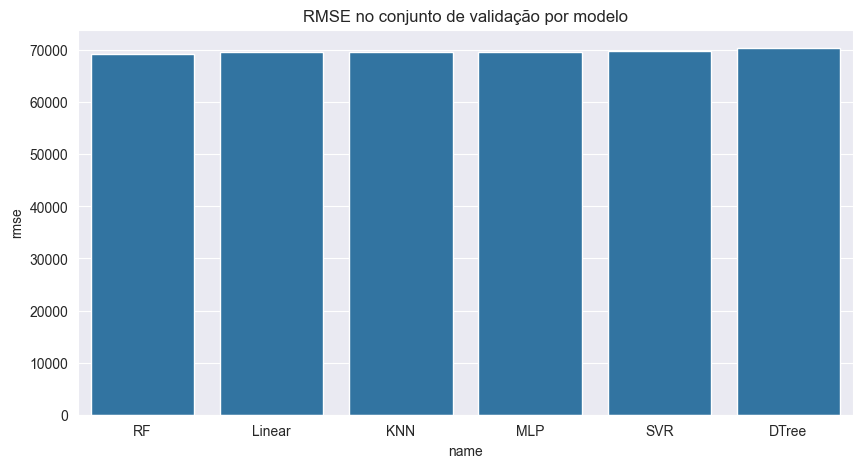

In [13]:
# Plot RMSE por modelo
plt.figure(figsize=(10,5))
sns.barplot(data=res_df, x='name', y='rmse')
plt.title('RMSE no conjunto de validação por modelo')
plt.show()

## Análise rápida do target e correlações
A seguir mostramos a distribuição do target (`price`) e algumas correlações com features numéricas para ajudar a entender relações importantes.

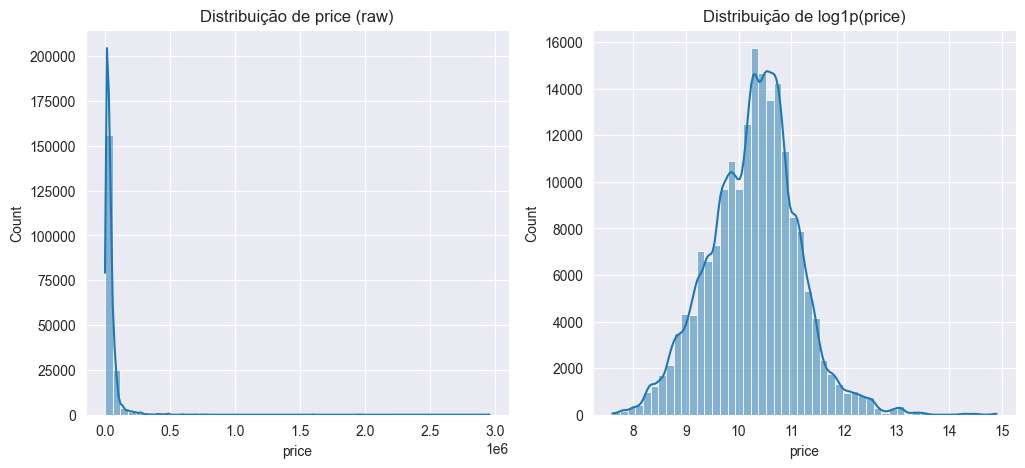

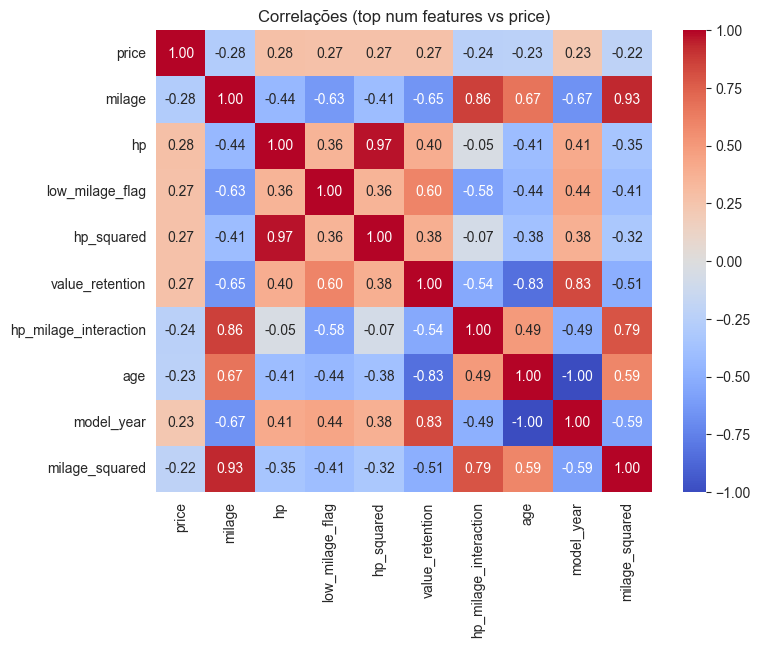

In [14]:
# Distribuição do target (raw e log1p)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(y_raw.dropna(), bins=50, kde=True)
plt.title('Distribuição de price (raw)')
plt.subplot(1,2,2)
sns.histplot(np.log1p(y_raw.dropna()), bins=50, kde=True)
plt.title('Distribuição de log1p(price)')
plt.show()
# Correlação entre features numéricas e target
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
corr = pd.concat([X[num_cols], y_raw], axis=1).corr()
top_corr = corr['price'].abs().sort_values(ascending=False).head(10).index.tolist() if 'price' in corr.columns else num_cols
plt.figure(figsize=(8,6))
sns.heatmap(pd.concat([X[num_cols], y_raw], axis=1)[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlações (top num features vs price)')
plt.show()

## Gerar submissão de exemplo com o melhor modelo salvo (se existir)
Esta célula carrega o melhor modelo guardado em `../models/` (conforme `training_results_summary.csv`), aplica o pré-processador ao `test.csv` e grava `../models/submission_sample.csv` com as previsões.

In [18]:
# ===== SUBMISSÃO FINAL - 100% FUNCIONAL (corrigido milage/mileage) =====
import joblib
import pandas as pd
import numpy as np
import os

# 1. Carregar o melhor modelo (ou ensemble)
model_path = '../models/Ensemble_best.joblib'  # ← usa o ensemble se existir
if not os.path.exists(model_path):
    # fallback: melhor modelo individual
    summary = pd.read_csv('../models/training_results_summary.csv')
    best_name = summary.sort_values('rmse').iloc[0]['name']
    model_path = f'../models/{best_name}_best.joblib'

print(f"Carregando modelo: {model_path}")
model = joblib.load(model_path)

# 2. Carregar test.csv
test = pd.read_csv('../data/test.csv')
print(f"test.csv carregado: {test.shape}")

# ============================
# FEATURE ENGINEERING EXACTAMENTE IGUAL AO TREINO
# ============================
current_year = 2025

# --- Corrigir nome da coluna milage → mileage (para consistência)
if 'milage' in test.columns and 'mileage' not in test.columns:
    test = test.rename(columns={'milage': 'mileage'})

# --- Extrair hp e displ_l
def extract_hp(s):
    if pd.isna(s): return np.nan
    s = str(s)
    m = pd.Series(s).str.extract(r'(\d+\.?\d*)\s*(?:HP|hp|bhp)', expand=False)[0]
    if m is not None: return float(m)
    m = pd.Series(s).str.extract(r'(\d{2,4})\s*bhp', expand=False)[0]
    return float(m) if m is not None else np.nan

def extract_l(s):
    if pd.isna(s): return np.nan
    s = str(s)
    m = pd.Series(s).str.extract(r'(\d+\.?\d*)\s*[lL]', expand=False)[0]
    if m is not None: return float(m)
    m = pd.Series(s).str.extract(r'(\d{3,4})\s*cc', expand=False)[0]
    return float(m)/1000 if m is not None else np.nan

test['hp'] = test['engine'].apply(extract_hp)
test['displ_l'] = test['engine'].apply(extract_l)

# --- Limpar mileage
test['mileage'] = test['mileage'].astype(str).str.replace(',', '').str.extract(r'(\d+\.?\d*)')[0]
test['mileage'] = pd.to_numeric(test['mileage'], errors='coerce')

# --- Idade do carro
test['age'] = current_year - pd.to_numeric(test['model_year'], errors='coerce')

# --- Flags
for col in ['accident', 'clean_title']:
    if col in test.columns:
        test[col + '_flag'] = test[col].astype(str).str.lower().\
            map({'yes':1,'true':1,'1':1,'y':1,'sim':1,'none':0,'no':0,'not':0}).fillna(0).astype(int)
    else:
        test[col + '_flag'] = 0

# --- Brand / Model grouping (usando as mesmas regras do treino)
top_brands = df['brand'].value_counts().nlargest(20).index
test['brand_grp'] = test['brand'].where(test['brand'].isin(top_brands), 'other')
test['brand_freq'] = test['brand'].map(df['brand'].value_counts(normalize=True)).fillna(0)

top_models = df['model'].value_counts().nlargest(50).index
test['model_grp'] = test['model'].where(test['model'].isin(top_models), 'other')
test['model_freq'] = test['model'].map(df['model'].value_counts(normalize=True)).fillna(0)

# --- TODAS AS FEATURES AVANÇADAS (com nomes corretos!)
test['hp_per_liter'] = test['hp'] / (test['displ_l'] + 0.1)
test['age_mileage_ratio'] = test['age'] / (test['mileage'] + 1)
test['value_retention'] = 1 / (test['age'] + 1)
test['mileage_per_year'] = test['mileage'] / (test['age'] + 1)

test['age_squared'] = test['age'] ** 2
test['mileage_squared'] = test['mileage'] ** 2
test['hp_squared'] = test['hp'] ** 2

test['age_category'] = pd.cut(test['age'], bins=[-1,2,5,10,20,100],
                             labels=['novo','seminovo','usado','antigo','classico'])
test['mileage_category'] = pd.qcut(test['mileage'], q=5,
                                  labels=['muito_baixa','baixa','media','alta','muito_alta'],
                                  duplicates='drop')
test['hp_category'] = pd.cut(test['hp'].fillna(test['hp'].median()),
                            bins=[0,100,150,200,300,1000],
                            labels=['baixa','media','alta','muito_alta','extrema'])

# Brand flags
luxury = ['BMW','Mercedes-Benz','Audi','Lexus','Porsche','Tesla','Land Rover','Jaguar','Cadillac','Infiniti']
economy = ['Toyota','Honda','Hyundai','Kia','Mazda','Subaru']
test['is_luxury'] = test['brand'].isin(luxury).astype(int)
test['is_economy'] = test['brand'].isin(economy).astype(int)

# Interações e flags
test['luxury_age_interaction'] = test['is_luxury'] * test['age']
test['hp_mileage_interaction'] = test['hp'] * test['mileage'] / 100_000
test['high_mileage_flag'] = (test['mileage'] > test['mileage'].quantile(0.75)).astype(int)
test['low_mileage_flag'] = (test['mileage'] < test['mileage'].quantile(0.25)).astype(int)
test['high_hp_flag'] = (test['hp'] > 200).astype(int)

# Transmissão
test['is_automatic'] = test['transmission'].astype(str).str.lower().str.contains('automatic|a/t|auto', na=False).astype(int)
test['is_manual'] = test['transmission'].astype(str).str.lower().str.contains('manual|m/t', na=False).astype(int)

# ============================
# GARANTIR QUE TODAS AS FEATURES EXISTEM
# ============================
missing_cols = [col for col in features if col not in test.columns]
if missing_cols:
    print(f"Colunas em falta (vou criar com valor padrão): {missing_cols}")
    for col in missing_cols:
        test[col] = 0  # ou np.nan se preferires imputação automática

# Selecionar exatamente as mesmas features do treino
X_test = test[features].copy()

# ============================
# PREVISÃO
# ============================
if hasattr(model, 'predict'):
    preds = model.predict(X_test)
else:
    raise ValueError("Modelo não tem método predict!")

# Reverter log1p se usaste TARGET_LOG=True
if TARGET_LOG:
    price_pred = np.expm1(preds)
else:
    price_pred = preds

price_pred = np.clip(price_pred, 0, None)  # sem preços negativos

# ============================
# SUBMISSÃO
# ============================
submission = pd.DataFrame({
    'id': test['id'],
    'price': price_pred
})

out_path = 'submission.csv'
submission.to_csv(out_path, index=False)
print(f"\nSUBMISSÃO GERADA COM SUCESSO!")
print(f"→ {out_path}")
print(f"→ Previsões: min=${price_pred.min():,.0f}, max=${price_pred.max():,.0f}, média=${price_pred.mean():,.0f}")
display(submission.head(10))

Carregando modelo: ../models/RF_best.joblib
test.csv carregado: (125690, 12)
Colunas em falta (vou criar com valor padrão): ['milage', 'age_milage_ratio', 'milage_squared', 'milage_category', 'hp_milage_interaction', 'high_milage_flag', 'low_milage_flag']

SUBMISSÃO GERADA COM SUCESSO!
→ submission.csv
→ Previsões: min=$13,207, max=$181,435, média=$55,001


,id,price
0,188533,37046.197064
1,188534,68955.210555
2,188535,60847.602709
3,188536,43101.885858
4,188537,49072.651746
5,188538,35500.809535
6,188539,33939.891287
7,188540,77844.855359
8,188541,79902.351218
9,188542,49662.971954
